# Simple fine-mapping and functional annotation of Alzheimer's risk loci

### Step 0: Import Statements

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import requests
from scipy.stats import chi2

### Step 1: Data Processing

We first read the summary statistics into a pandas DataFrame and check the data's attributes — its shape, its unique columns, any N/A values, the range of its p-values, etc.

In [3]:
file = "data/raw/Kunkle_etal_Stage1_results.txt"
df = pd.read_csv(file, sep=r"\s+")
print("shape", df.shape)
print("columns", list(df.columns))
print("dtypes", list(df.dtypes))
print(df.isna().sum())
df.head()

shape (11480632, 8)
columns ['Chromosome', 'Position', 'MarkerName', 'Effect_allele', 'Non_Effect_allele', 'Beta', 'SE', 'Pvalue']
dtypes [dtype('int64'), dtype('int64'), dtype('O'), dtype('O'), dtype('O'), dtype('float64'), dtype('float64'), dtype('float64')]
Chromosome              0
Position                0
MarkerName           2287
Effect_allele           0
Non_Effect_allele       0
Beta                    0
SE                      0
Pvalue                  0
dtype: int64


,Chromosome,Position,MarkerName,Effect_allele,Non_Effect_allele,Beta,SE,Pvalue
0,1,100000012,rs10875231,T,G,-0.0026,0.0168,0.8758
1,1,100000827,rs6678176,T,C,0.0008,0.0156,0.9574
2,1,100000843,rs78286437,T,C,-0.0136,0.0330,0.6792
3,1,100000989,chr1:100000989:I,A,ATC,-0.0099,0.0343,0.7731
4,1,100001138,rs144406489,A,G,-0.0061,0.0612,0.9204


In [4]:
print("P range:", df["Pvalue"].min(), "to", df["Pvalue"].max())
print("missing P:", df["Pvalue"].isna().sum())
print("chromosomes:", sorted(df["Chromosome"].unique().tolist()))
print("N variants:", len(df))

P range: 0.0 to 1.0
missing P: 0
chromosomes: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]
N variants: 11480632


We'll now graph a Manhattan plot and a QQ plot. Each point of a Manhattan plot represents an SNP. The x-axis is its genome location and the y-axis is its −log_10(p) value. Spikes on the Manhattan plot represent SNPs that have a statistically significant association with Alzheimer's disease. A QQ plot graphs the expected -log_10(p) values (the x-axis) against the observed -log_10(p) values (the y-axis). If the points stray from the diagonal, inflation is present.

In [5]:
def manhattan_plot(df, ax):
    data = df[["Chromosome", "Position", "Pvalue"]].dropna().copy()
    chromosomes = sorted(data["Chromosome"].unique())
    strong = data[data["Pvalue"] < 1e-3]
    rest = data[data["Pvalue"] >= 1e-3].sample(frac=0.08, random_state=0)
    data = pd.concat([strong, rest]).sort_values(["Chromosome", "Position"])
    offsets = {}
    location = 0
    for c in chromosomes:
        offsets[c] = location
        location += data.loc[data["Chromosome"] == c, "Position"].max()
    data["Genome_Location"] = data["Position"] + data["Chromosome"].map(offsets)
    data["mlogp"] = -np.log10(data["Pvalue"])
    ticks, labels = [], []
    for c in chromosomes:
        chr = data[data["Chromosome"] == c]
        ax.scatter(chr["Genome_Location"], chr["mlogp"], s=3, rasterized=True)
        ticks.append(offsets[c] + chr["Position"].max()/2)
        labels.append(c)
    ax.axhline(-np.log10(5e-8), color="red", linestyle="dashed", lw=1)
    ax.set_xticks(ticks)
    ax.set_xticklabels(labels, fontsize=5)
    ax.set_xlabel("Chromosome")
    ax.set_ylabel("-Log_P")

def qq_plot(df, ax):
    p = df["Pvalue"].dropna().values
    p = p[(p > 0) & (p <= 1)]
    n = len(p)
    observed = -np.log10(np.sort(p))
    expected = -np.log10((np.arange(1, n + 1) - 0.5) / n)
    chi_squared = chi2.isf(p, df=1)
    lam = np.median(chi_squared) / chi2.ppf(0.5, df=1)
    index = np.union1d(np.arange(min(20000, n)),
                       np.linspace(0, n - 1, 20000).astype(int))
    ax.scatter(expected[index], observed[index], s=4, rasterized=True)
    limits = max(expected.max(), observed.max())
    ax.plot([0, limits], [0, limits], color="red", linestyle="dashed", lw=1)
    ax.set_xlabel("Expected -Log-P Value")
    ax.set_ylabel("Observed -Log-P Value")
    ax.set_title(f"Lambda GC = {lam: .3f}")
    return lam

lambda_GC = 1.0596


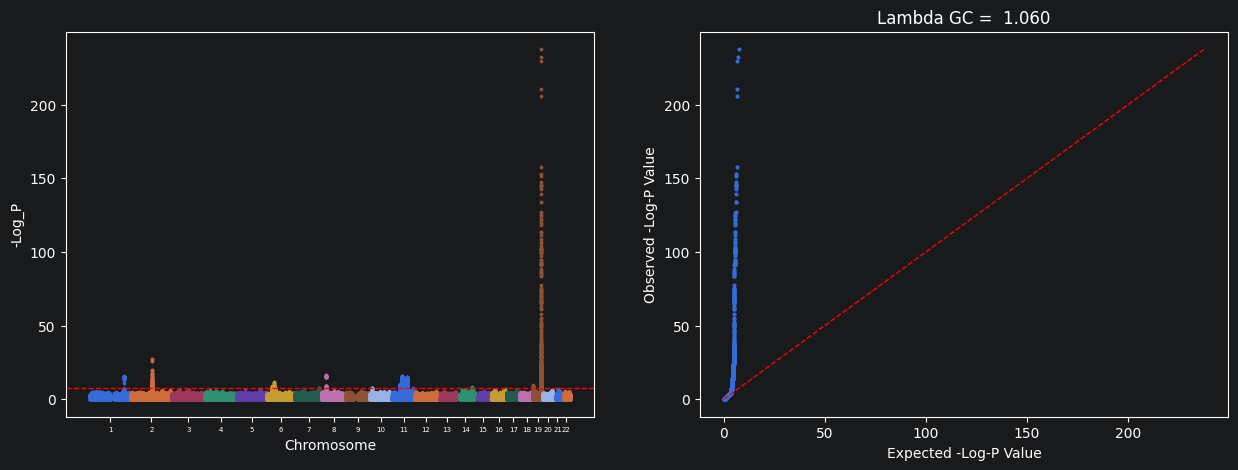

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
manhattan_plot(df, axes[0])
lam = qq_plot(df, axes[1])
plt.savefig("results/figures/manhattan_qq.png", dpi=300)
print("lambda_GC =", round(lam, 4))
plt.show()

Notice that there's a huge spike at Chromosome 19 on the Manhattan plot. That's the APOE locus, which is strongly associated with Alzheimer's. The APOE gene makes a protein that handles fats and cholesterol in the body. It has three main types: ε2, ε3, and ε4. Carrying the ε4 allele makes one have higher risk for Alzheimer's.

### Step 2: Evaluating Heritability and Confounding Factors

From the previous section, we see that the λ_GC value — the genomic inflation factor — is around 1.06. This indicates inflation, but we're not yet able to tell if it's because of confounding factors in the data or a polygenicity. We'll run LDSC to find out; first, we'll munge the data.

In [7]:
with open("ldsc/ad.log") as file:
    log = file.read()
print(log)

*********************************************************************
* LD Score Regression (LDSC)
* Version 1.0.1
* (C) 2014-2019 Brendan Bulik-Sullivan and Hilary Finucane
* Broad Institute of MIT and Harvard / MIT Department of Mathematics
* GNU General Public License v3
*********************************************************************
Call: 
./munge_sumstats.py \
--signed-sumstats Beta,0 \
--out ad \
--merge-alleles w_hm3.snplist \
--N 63926.0 \
--a1 Effect_allele \
--a2 Non_Effect_allele \
--snp MarkerName \
--sumstats ../data/raw/Kunkle_etal_Stage1_results.txt \
--p Pvalue 

Interpreting column names as follows:
Effect_allele:	Allele 1, interpreted as ref allele for signed sumstat.
MarkerName:	Variant ID (e.g., rs number)
Beta:	Directional summary statistic as specified by --signed-sumstats.
Pvalue:	p-Value
Non_Effect_allele:	Allele 2, interpreted as non-ref allele for signed sumstat.

Reading list of SNPs for allele merge from w_hm3.snplist
Read 1217311 SNPs for allele merge

The mean χ² value of 1.117, along with the λ_GC value of 1.091, indicates true inflation; the max χ² value of 689.86 indicates the presence of very strong genome-wide significant loci.

Next, we'll run ldsc.py. Since we don't have a clean population prevalence value for Alzheimer's, we'll use a range of values.

In [8]:
n_cases = 21982
n_control = 41944
n_total = n_cases + n_control
sample_prevalence = n_cases / n_total

print("Total: ", n_total)
print("Cases: ", n_cases)
print("Control: ", n_control)
print("Sample Prevalence (to be used in LDSC): ", sample_prevalence)

Total:  63926
Cases:  21982
Control:  41944
Sample Prevalence (to be used in LDSC):  0.3438663454619404


In [9]:
for prev in ["0.05", "0.10", "0.15", "0.20"]:
    with open(f"ldsc/alzheimers_h2_prev{prev}.log") as file:
        log = file.read()
    print(log,"\n")

*********************************************************************
* LD Score Regression (LDSC)
* Version 1.0.1
* (C) 2014-2019 Brendan Bulik-Sullivan and Hilary Finucane
* Broad Institute of MIT and Harvard / MIT Department of Mathematics
* GNU General Public License v3
*********************************************************************
Call: 
./ldsc.py \
--h2 ad.sumstats.gz \
--ref-ld-chr eur_w_ld_chr/ \
--out alzheimers_h2_prev0.05 \
--pop-prev 0.05 \
--samp-prev 0.344 \
--w-ld-chr eur_w_ld_chr/ 

Beginning analysis at Thu Jul 30 10:04:04 2026
Reading summary statistics from ad.sumstats.gz ...
Read summary statistics for 1207072 SNPs.
Reading reference panel LD Score from eur_w_ld_chr/[1-22] ... (ldscore_fromlist)
Read reference panel LD Scores for 1290028 SNPs.
Removing partitioned LD Scores with zero variance.
Reading regression weight LD Score from eur_w_ld_chr/[1-22] ... (ldscore_fromlist)
Read regression weight LD Scores for 1290028 SNPs.
After merging with reference panel

In all the runs, the intercept was around 1.03, suggesting that the inflation we saw is primarily because of polygenicity, rather than any confounding factors or issues in the data.

### Step 3: Quality Control + Preparing Data for Clumping

To prepare the data for clumping, we'll round up p-values equal to zero, drop any N/A values in the SNP column, and make sure every SNP has a valid rsID.

In [10]:
qc = df[(df["Pvalue"] >= 0) & (df["Pvalue"] <= 1)].copy()
qc["Pvalue"] = qc["Pvalue"].replace(0, np.nextafter(0, 1))
qc = qc[["MarkerName", "Pvalue"]].rename(
    columns={"MarkerName": "SNP", "Pvalue": "P"}
)
qc = qc.dropna(subset=["SNP"])
qc = qc[qc["SNP"].str.startswith("rs")]
qc.to_csv("data/processed/ad_for_clump.txt", sep="\t", index=False)

print(f"{len(df):,} -> {len(qc):,} after QC")

11,480,632 -> 10,534,426 after QC


### Step 4 - Clumping

We run LD clumping in PLINK, which groups correlated SNPs around top asociation signals. PLINK selects a lead SNP passing the index threshold, and assigns SNPs to the clump depending on a set of parameters. The index threshold, or standard genome-wide significance threshold, was 5x10e-8. The secondary threshold was 0.01; the window size was 500 kb; and r^2 was 0.1. These are conventional values for fine-mapping GWAS summary statistics.

In [11]:
clumped = pd.read_csv("data/processed/ad_clumped.clumped", sep=r"\s+")
print("loci:", len(clumped))
print(clumped.columns.tolist())
clumped.head()

loci: 72
['CHR', 'F', 'SNP', 'BP', 'P', 'TOTAL', 'NSIG', 'S05', 'S01', 'S001', 'S0001', 'SP2']


,CHR,F,SNP,BP,P,TOTAL,NSIG,S05,S01,S001,S0001,SP2
0,19,1,rs12972156,45387459,4.940656e-324,23,0,0,0,0,23,"rs147711004(1),rs41289512(1),rs146275714(1),rs..."
1,19,1,rs28399664,45324756,1.210000e-158,1,0,0,0,0,1,rs142034848(1)
2,19,1,rs157580,45395266,4.800000e-152,82,0,0,0,2,80,"rs7026(1),rs8112196(1),rs6509172(1),rs10406338..."
3,19,1,rs3925681,45421100,2.610000e-125,14,1,2,1,0,10,"rs11667610(1),rs12971462(1),rs71364511(1),rs12..."
4,19,1,rs28399637,45324138,2.090000e-120,24,4,2,0,0,18,"rs2889414(1),rs7359852(1),rs3021439(1),rs29274..."


In [12]:
print(clumped["CHR"].value_counts().sort_index())

CHR
1      1
2      3
6      3
7      1
8      2
10     1
11     5
14     1
19    55
Name: count, dtype: int64


Clumping yields 72 loci. Grouped by chromosome, we see 55 fall on Chromosome 19, where APOE is located. This raises the question — is APOE distorting our analysis? What happens if we zoom in on the other loci by removing it?

### Step 5 - No-APOE Analysis

We'll first create a no-APOE dataset by filering out SNPs between 44,400,000 and 46,400,000 bp on Chromosome 19. This is a larger range than the documented APOE coordinates, but we'll choose it to encompas the region's extended LD.

In [13]:
no_apoe_df = df[~((df["Chromosome"] == 19) & (df["Position"].between(44_400_000, 46_400_000)))].copy()
print("shape", no_apoe_df.shape)
print("columns", list(no_apoe_df.columns))
print("dtypes", list(no_apoe_df.dtypes))
print(no_apoe_df.isna().sum())
no_apoe_df.head()

shape (11472352, 8)
columns ['Chromosome', 'Position', 'MarkerName', 'Effect_allele', 'Non_Effect_allele', 'Beta', 'SE', 'Pvalue']
dtypes [dtype('int64'), dtype('int64'), dtype('O'), dtype('O'), dtype('O'), dtype('float64'), dtype('float64'), dtype('float64')]
Chromosome              0
Position                0
MarkerName           2286
Effect_allele           0
Non_Effect_allele       0
Beta                    0
SE                      0
Pvalue                  0
dtype: int64


,Chromosome,Position,MarkerName,Effect_allele,Non_Effect_allele,Beta,SE,Pvalue
0,1,100000012,rs10875231,T,G,-0.0026,0.0168,0.8758
1,1,100000827,rs6678176,T,C,0.0008,0.0156,0.9574
2,1,100000843,rs78286437,T,C,-0.0136,0.0330,0.6792
3,1,100000989,chr1:100000989:I,A,ATC,-0.0099,0.0343,0.7731
4,1,100001138,rs144406489,A,G,-0.0061,0.0612,0.9204


In [14]:
print("P range:", no_apoe_df["Pvalue"].min(), "to", no_apoe_df["Pvalue"].max())
print("missing P:", no_apoe_df["Pvalue"].isna().sum())
print("chromosomes:", sorted(no_apoe_df["Chromosome"].unique().tolist()))
print("N variants:", len(no_apoe_df))

P range: 4.022e-28 to 1.0
missing P: 0
chromosomes: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]
N variants: 11472352


We can see an immediate change when we preview the data. The minimum p-valeu for the no-APOE dataset is 4.022x10e-28, whereas it was 0 (an underflow) for the APOE-inclusive dataset. We also lose 8,280 variants.

lambda_GC = 1.059


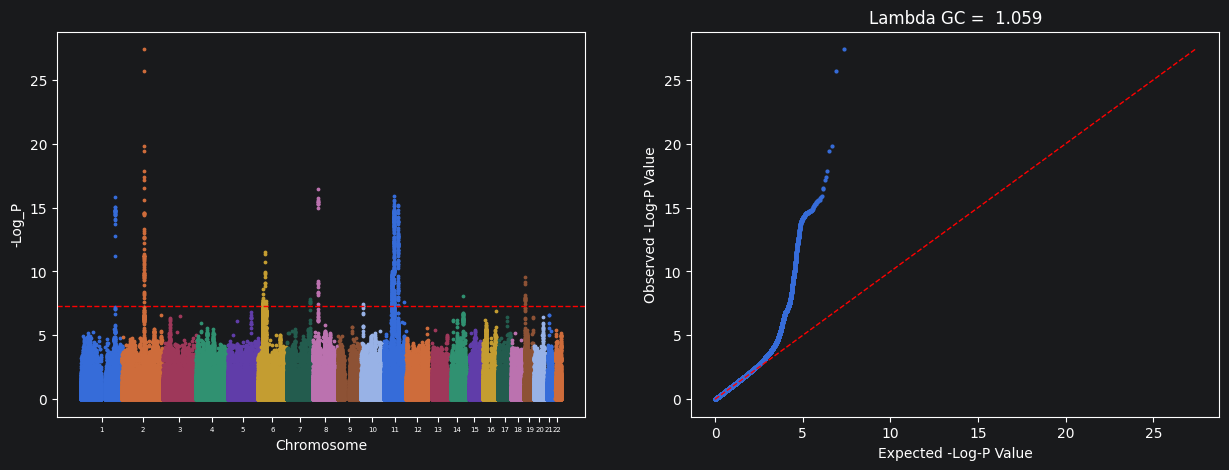

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
manhattan_plot(no_apoe_df, axes[0])
lam = qq_plot(no_apoe_df, axes[1])
plt.savefig("results/figures/manhattan_qq_no_apoe.png", dpi=300)
print("lambda_GC =", round(lam, 3))
plt.show()

Many more peaks are now distinguishable in the Manhattan plot. The most noticeable peaks are on Chromosomes 2 and 11. (SORL1, on Chromosome 11, is linked to beta-amyloid production and Alzheimer's disease). The QQ plot again shows inflation.

In [16]:
no_apoe_df.to_csv("data/processed/ad_no_apoe.tsv", sep="\t", index=False)

In [17]:
with open("ldsc/ad_no_apoe.log") as file:
    log = file.read()
print(log)

*********************************************************************
* LD Score Regression (LDSC)
* Version 1.0.1
* (C) 2014-2019 Brendan Bulik-Sullivan and Hilary Finucane
* Broad Institute of MIT and Harvard / MIT Department of Mathematics
* GNU General Public License v3
*********************************************************************
Call: 
./munge_sumstats.py \
--signed-sumstats Beta,0 \
--out ad_no_apoe \
--merge-alleles w_hm3.snplist \
--N 63926.0 \
--a1 Effect_allele \
--a2 Non_Effect_allele \
--snp MarkerName \
--sumstats ../data/processed/ad_no_apoe.tsv \
--p Pvalue 

Interpreting column names as follows:
Effect_allele:	Allele 1, interpreted as ref allele for signed sumstat.
MarkerName:	Variant ID (e.g., rs number)
Beta:	Directional summary statistic as specified by --signed-sumstats.
Pvalue:	p-Value
Non_Effect_allele:	Allele 2, interpreted as non-ref allele for signed sumstat.

Reading list of SNPs for allele merge from w_hm3.snplist
Read 1217311 SNPs for allele merge.


Rerunning munge_sumstats.py, the mean χ² value of 1.105 and the λ_GC value of 1.09 indicates inflation, and the max χ² value of 84.723 reflects genome-wide significance.

In [18]:
for prev in ["0.05", "0.10", "0.15", "0.20"]:
    with open(f"ldsc/ad_no_apoe_h2_prev{prev}.log") as file:
        log = file.read()
    print(log)

*********************************************************************
* LD Score Regression (LDSC)
* Version 1.0.1
* (C) 2014-2019 Brendan Bulik-Sullivan and Hilary Finucane
* Broad Institute of MIT and Harvard / MIT Department of Mathematics
* GNU General Public License v3
*********************************************************************
Call: 
./ldsc.py \
--h2 ad_no_apoe.sumstats.gz \
--ref-ld-chr eur_w_ld_chr/ \
--out ad_no_apoe_h2_prev0.05 \
--pop-prev 0.05 \
--samp-prev 0.344 \
--w-ld-chr eur_w_ld_chr/ 

Beginning analysis at Thu Jul 30 12:59:24 2026
Reading summary statistics from ad_no_apoe.sumstats.gz ...
Read summary statistics for 1206238 SNPs.
Reading reference panel LD Score from eur_w_ld_chr/[1-22] ... (ldscore_fromlist)
Read reference panel LD Scores for 1290028 SNPs.
Removing partitioned LD Scores with zero variance.
Reading regression weight LD Score from eur_w_ld_chr/[1-22] ... (ldscore_fromlist)
Read regression weight LD Scores for 1290028 SNPs.
After merging with

Rerunning ldsc.py across the same range of prevalence values gives an intercept of 1.025 (with a standarderror of 0.0066), which again indicates polygenic signal. To compare LDSC heritability between the no-APOE and full data, see the table in the README. **Overall, excluding the APOE locus resulted in a modest decrease in liability-scale heritability across all prevalence values. So while APOE contributes substantially to Alzheimer's disease risk, a large proportion of common-variant heritability can be attributed to loci elsewhere.**

We'll again run LD clumping on PLINK with the conventional parameters. To prepare the no-APOE data for clumping, we'll again round up p-values equal to zero, drop N/A values in the SNP column, and ensure every SNP has a valid rsID.

In [19]:
qc_no_apoe = no_apoe_df[(no_apoe_df["Pvalue"] >= 0) & (no_apoe_df["Pvalue"] <= 1)].copy()
qc_no_apoe["Pvalue"] = qc_no_apoe["Pvalue"].replace(0, np.nextafter(0, 1))
qc_no_apoe = qc_no_apoe[["MarkerName", "Pvalue"]].rename(
    columns={"MarkerName": "SNP", "Pvalue": "P"}
)
qc_no_apoe = qc_no_apoe.dropna(subset=["SNP"])
qc_no_apoe = qc_no_apoe[qc_no_apoe["SNP"].str.startswith("rs")]
qc_no_apoe.to_csv("data/processed/ad_no_apoe_for_clump.txt", sep="\t", index=False)

print(f"{len(no_apoe_df):,} -> {len(qc_no_apoe):,} after QC")

11,472,352 -> 10,526,914 after QC


In [43]:
clumped = pd.read_csv("data/processed/ad_no_apoe_clumped.clumped", sep=r"\s+")
clump_snps = set(clumped["SNP"])
print("clumped loci:", len(clumped))
print(clumped.columns.tolist())
clumped.head()

clumped loci: 19
['CHR', 'F', 'SNP', 'BP', 'P', 'TOTAL', 'NSIG', 'S05', 'S01', 'S001', 'S0001', 'SP2']


,CHR,F,SNP,BP,P,TOTAL,NSIG,S05,S01,S001,S0001,SP2
0,2,1,rs6733839,127892810,4.020000e-28,127,0,0,27,12,88,"rs72843823(1),rs749254(1),rs72843885(1),rs7284..."
1,8,1,rs867230,27468503,3.490000e-17,106,25,5,25,17,34,"rs2640724(1),rs17466060(1),rs9632863(1),rs1565..."
2,11,1,rs1582763,60021948,1.190000e-16,460,0,3,46,4,407,"rs509968(1),rs11825794(1),rs11821744(1),rs1286..."
3,1,1,rs679515,207750568,1.560000e-16,175,7,10,82,13,63,"rs6666604(1),rs61821042(1),rs4844574(1),rs4844..."
4,11,1,rs3851179,85868640,5.810000e-16,466,58,27,34,128,219,"rs78563874(1),rs7106460(1),rs7106577(1),rs1132..."


In [21]:
print(clumped["CHR"].value_counts().sort_index())

CHR
1     1
2     3
6     3
7     1
8     2
10    1
11    5
14    1
19    2
Name: count, dtype: int64


Re-clumping gives us 19 loci, of which this time, only 2 are on Chromosome 19. The most loci, 5, are found on Chromosome 11, followed by Chromosomes 2 and 6, each of which have 3.

### Step 6 - Functional Annotation, Pass 1

In this step, we'll find the nearest genes to each locus. We'll first read the reference genome gene annotations from the UCSC Genome Browser into a pandas DataFrame, and ensure all the chromosomes on it are between 1 and 23, or X or Y. We'll then build a BED file from it.

In [22]:
cols = ["bin","name","chrom","strand","txStart","txEnd","cdsStart","cdsEnd",
        "exonCount","exonStarts","exonEnds","score","name2","cdsStartStat",
        "cdsEndStat","exonFrames"]
ref = pd.read_csv("data/raw/refGene.txt", sep="\t", names=cols)
print("loaded rows:", len(ref))
print("chromosome examples:", ref["chrom"].head(5).tolist())

loaded rows: 81407
chromosome examples: ['chr3', 'chr3', 'chr13', 'chr1', 'chr1']


In [23]:
valid_chr = ["X", "Y"]
for num in np.arange(1, 24):
    valid_chr.append("chr" + str(num))
ref = ref[ref["chrom"].isin(valid_chr)]
print("after filter:", len(ref))

after filter: 74656


In [24]:
bed = ref[["chrom", "txStart", "txEnd", "name2"]].drop_duplicates()
bed.to_csv("data/raw/genes_hg19.bed", sep="\t", index=False, header=False)
print(len(bed), "gene entries")
bed.head()

42845 gene entries


,chrom,txStart,txEnd,name2
0,chr3,196666747,196669405,NCBP2-AS1
1,chr3,192232810,192234362,FGF12-AS2
2,chr13,95364969,95368199,SOX21-AS1
3,chr1,17368,17436,MIR6859-1
4,chr1,17368,17436,MIR6859-2


In [25]:
loci = clumped[["CHR", "BP", "SNP"]].copy()
loci["chrom"] = "chr" + loci["CHR"].astype(str)
loci["start"] = loci["BP"] - 1
loci["end"] = loci["BP"]
loci[["chrom", "start", "end", "SNP"]].to_csv("data/processed/ad_loci.bed", sep="\t", index=False, header=False)
print(len(loci), "loci entries")

19 loci entries


We run bedtools closest with -a as the sorted no-APOE loci BED (ad_loci.bed) and -b as the gene-annotation BED (genes_hg19.bed), with -d enabled, which appends the distance to the nearest gene (0 indicates the SNP lies in the gene). The output is the nearest gene and its distance for each lead SNP.

In [44]:
cols = ["chrom", "start", "end", "SNP", "g_chrom", "g_start", "g_end", "gene", "dist"]
near = pd.read_csv("data/processed/ad_nearest_genes.txt", sep="\t", names=cols)
near_snps = set(near["SNP"])
print(near)

    chrom      start        end          SNP g_chrom    g_start      g_end  \
0    chr1  207750567  207750568     rs679515    chr1  207669501  207815110   
1   chr10   11721056   11721057   rs12416487   chr10   11784380   11806069   
2   chr11   47380339   47380340    rs3740688   chr11   47376410   47400098   
3   chr11   60021947   60021948    rs1582763   chr11   59968725   60010610   
4   chr11   85868639   85868640    rs3851179   chr11   85955425   85989852   
5   chr11  121435586  121435587   rs11218343   chr11  121323022  121504472   
6   chr14   92938854   92938855   rs12590654   chr14   92788924   92967825   
7   chr14   92938854   92938855   rs12590654   chr14   92789508   92967825   
8   chr19    1047077    1047078    rs4147910   chr19    1040105    1065570   
9   chr19    1050873    1050874   rs12151021   chr19    1040105    1065570   
10   chr2  127841768  127841769   rs10200967    chr2  127805598  127842126   
11   chr2  127841768  127841769   rs10200967    chr2  127805607 

In [27]:
clean = (near[["SNP", "chrom", "gene", "dist"]].sort_values("dist").drop_duplicates(subset=["SNP", "gene"]))
print(clean)

            SNP  chrom       gene   dist
0      rs679515   chr1        CR1      0
22     rs867230   chr8        CLU      0
21   rs73223431   chr8      PTK2B      0
17   rs11767557   chr7  EPHA1-AS1      0
15  rs114812713   chr6      OARD1      0
11   rs10200967   chr2       BIN1      0
9    rs12151021  chr19      ABCA7      0
8     rs4147910  chr19      ABCA7      0
7    rs12590654  chr14    SLC24A4      0
5    rs11218343  chr11      SORL1      0
2     rs3740688  chr11       SPI1      0
16    rs1385742   chr6      CD2AP    159
14   rs34665982   chr6   HLA-DRB1   2693
3     rs1582763  chr11     MS4A4E  11338
12    rs6710467   chr2       BIN1  25202
13    rs6733839   chr2       BIN1  28080
1    rs12416487  chr10     ECHDC3  63324
4     rs3851179  chr11        EED  86786


In [51]:
missing_snp = clump_snps - near_snps
print("Clumped SNPs that were NOT annotated:", missing_snp)

Clumped SNPs that were NOT annotated: {'rs34467936'}


According to the GWAS catalog, rs34467936 is a variant located on Chromosome 11. It's been mapped to two protein-coding genes, NUP160 and PTPRJ. PTPRJ is primarily a tumor suppressor gene. NUP160 is involved in mRNA export from the nucleus and nephron development. It's associated with nephrotic syndrome type 19. The variant likely does not appear in the reference gene BED file, and so couldn't be annotated.

### Step 7 - Functional Annotation, Pass 2

In the previous step, we assigned genes by proximity alone. However, physical closeness isn't always the right metric; loci can regulate genes that are far away. eQTL (expression quantitative trait locus) evidence provides statistical links between a variant and a gene's expression. In this step, we'll query the GTEx API and retrieve the corresponding brain tissues and genes for each SNP.

We have to query tissues and genes by each SNP's variant ID; the variant ID is different from the rsIDs we have stored. So we'll first retrieve the variant ID for each SNP, and then get the corresponding tissue and gene.

In [28]:
def rsid_to_variant_id(rsid):
    r = requests.get("https://gtexportal.org/api/v2/dataset/variant",
                     params={"snpId": rsid, "datasetId": "gtex_v8"})
    d = r.json().get("data", [])
    if (d is None) or (len(d) <= 0):
        return None
    else:
        return d[0]["variantId"]

In [29]:
def brain_eqtls(rsid):
    r = requests.get("https://gtexportal.org/api/v2/association/singleTissueEqtl", params={"variantId": rsid_to_variant_id(rsid), "datasetID": "gtex_v8", "itemsPerPage": 100000})
    tissues = r.json().get("data", [])
    brain = []
    for t in tissues:
        if t["tissueSiteDetailId"].startswith("Brain"):
            brain.append(t)
    return brain

In [30]:
snps = loci["SNP"]
brain_tissues = []
for rsid in snps:
    results = brain_eqtls(rsid)
    brain_tissues.append(results)

print(len(brain_tissues), "SNPs processed")

19 SNPs processed


In [46]:
rows = []
for rsid, results in zip(snps, brain_tissues):
    if results is None or len(results) == 0:
       rows.append({"SNP": rsid, "gene": None, "tissue": None, "pValue": None, "nes": None})
       continue
    for r in results:
        rows.append({"SNP": rsid, "gene": r["geneSymbol"], "tissue": r["tissueSiteDetailId"], "pValue": r["pValue"], "nes": r["nes"]})

eqtl = pd.DataFrame(rows)
eqtl_snps = set(eqtl["SNP"])
print(len(eqtl_snps), "SNPs found")
print(eqtl.shape)

19 SNPs found
(69, 5)


In [47]:
print(eqtl)

           SNP             gene                                 tissue  \
0    rs6733839             BIN1                       Brain_Cerebellum   
1    rs6733839  ENSG00000286971         Brain_Spinal_cord_cervical_c-1   
2     rs867230              CLU  Brain_Nucleus_accumbens_basal_ganglia   
3     rs867230           CHRNA2            Brain_Cerebellar_Hemisphere   
4    rs1582763             None                                   None   
..         ...              ...                                    ...   
64   rs4147910           RNU6-2                           Brain_Cortex   
65  rs11767557            TCAF2  Brain_Nucleus_accumbens_basal_ganglia   
66   rs1385742             None                                   None   
67  rs11218343             None                                   None   
68  rs12416487             None                                   None   

          pValue       nes  
0   7.956986e-06 -0.208341  
1   5.204420e-07  0.455270  
2   2.440602e-08 -0.1733

In [48]:
print("total eQTL associations:", len(eqtl))
print("SNPs with more than 1 brain eQTL:", eqtl.dropna(subset=["gene"])["SNP"].nunique(), "of 19")
print("distinct genes:", eqtl["gene"].nunique())
print("rows per SNP:")
print(eqtl.groupby("SNP").size().sort_values(ascending=False))

total eQTL associations: 69
SNPs with more than 1 brain eQTL: 12 of 19
distinct genes: 19
rows per SNP:
Clumped SNPs NOT found in eQTL:  set()
SNP
rs3740688      34
rs679515       12
rs10200967      3
rs4147910       3
rs6733839       2
rs867230        2
rs12590654      1
rs1385742       1
rs1582763       1
rs11218343      1
rs34665982      1
rs12416487      1
rs3851179       1
rs12151021      1
rs6710467       1
rs11767557      1
rs114812713     1
rs73223431      1
rs34467936      1
dtype: int64


For each SNP, we get multiple corresponding genes and tissues. We'll check if the gene we identified in Pass 1 matches the SNP's strongest eQTL gene match.

In [56]:
best = (eqtl.dropna(subset=["gene"])
        .sort_values("pValue")
        .drop_duplicates("SNP")
        .rename(columns={"gene":"eqtl_gene"}))
non_na_snps = set(best["SNP"])
dropped_snps = eqtl_snps - non_na_snps
print("SNPs dropped:", dropped_snps)

SNPs dropped: {'rs11218343', 'rs1385742', 'rs12416487', 'rs114812713', 'rs34665982', 'rs1582763', 'rs34467936'}


In [57]:
pass1 = clean[["SNP","gene"]].rename(columns={"gene":"nearest_gene"})
compare = pass1.merge(best, on="SNP", how="left")
compare["match"] = compare["nearest_gene"] == compare["eqtl_gene"]
print(compare)

            SNP nearest_gene        eqtl_gene  \
0      rs679515          CR1              CR1   
1      rs867230          CLU              CLU   
2    rs73223431        PTK2B           CHRNA2   
3    rs11767557    EPHA1-AS1            TCAF2   
4   rs114812713        OARD1              NaN   
5    rs10200967         BIN1             BIN1   
6    rs12151021        ABCA7         ARHGAP45   
7     rs4147910        ABCA7           RNU6-2   
8    rs12590654      SLC24A4             RIN3   
9    rs11218343        SORL1              NaN   
10    rs3740688         SPI1            MTCH2   
11    rs1385742        CD2AP              NaN   
12   rs34665982     HLA-DRB1              NaN   
13    rs1582763       MS4A4E              NaN   
14    rs6710467         BIN1             BIN1   
15    rs6733839         BIN1  ENSG00000286971   
16   rs12416487       ECHDC3              NaN   
17    rs3851179          EED  ENSG00000279742   

                                   tissue        pValue       nes  m

In [58]:
compare_eqtl = compare.dropna(subset=["eqtl_gene"])[["SNP", "nearest_gene", "eqtl_gene", "match"]]
print(compare_eqtl)

           SNP nearest_gene        eqtl_gene  match
0     rs679515          CR1              CR1   True
1     rs867230          CLU              CLU   True
2   rs73223431        PTK2B           CHRNA2  False
3   rs11767557    EPHA1-AS1            TCAF2  False
5   rs10200967         BIN1             BIN1   True
6   rs12151021        ABCA7         ARHGAP45  False
7    rs4147910        ABCA7           RNU6-2  False
8   rs12590654      SLC24A4             RIN3  False
10   rs3740688         SPI1            MTCH2  False
14   rs6710467         BIN1             BIN1   True
15   rs6733839         BIN1  ENSG00000286971  False
17   rs3851179          EED  ENSG00000279742  False


In [59]:
num_matches = compare_eqtl["match"].sum()
total_not_na = len(compare_eqtl)
percent_match = (num_matches / total_not_na) * 100
print(f"{num_matches} matches out of {total_not_na} non-N/A genes")

4 matches out of 12 non-N/A genes


We can see that of the non-N/A values, a third of the genes from Pass 1 matched the eQTL genes from Pass 2. It is important to note that the two eQTL genes at the end, ENSG00000286971 and ENSG00000279742, are genes without a neat characterization. We can also do a broader check and see if the gene identified in Pass 1 appears at any point in the SNP's list of eQTL genes.

We'll create a function that checks if the gene we identified in Pass 1 is one of the SNP's eQTL genes and classifies it with the appropriate label.

In [60]:
eqtl_genes_per_snp = eqtl.dropna(subset=["gene"]).groupby("SNP")["gene"].apply(set)

def classify(row):
    genes = eqtl_genes_per_snp.get(row["SNP"])
    if genes is None:            return "no_eQTL"
    if row["nearest_gene"] in genes: return "nearest_gene_confirmed"
    return "different_gene_only"

compare["status"] = compare.apply(classify, axis=1)
compare["status"].value_counts()

status
different_gene_only       7
no_eQTL                   6
nearest_gene_confirmed    5
Name: count, dtype: int64

Allowing the nearest gene to appear anywhere in the eQTL set, we see that 5 loci were confirmed, 7 were found in a different gene, and 6 had no brain eQTL. 1 locus had no nearest gene identified in the first place. The 7 loci with different genes are listed below.

In [39]:
different = compare[compare["status"]=="different_gene_only"][["SNP", "nearest_gene", "eqtl_gene", "tissue"]]
print(different)

           SNP nearest_gene        eqtl_gene  \
2   rs73223431        PTK2B           CHRNA2   
3   rs11767557    EPHA1-AS1            TCAF2   
6   rs12151021        ABCA7         ARHGAP45   
7    rs4147910        ABCA7           RNU6-2   
8   rs12590654      SLC24A4             RIN3   
10   rs3740688         SPI1            MTCH2   
17   rs3851179          EED  ENSG00000279742   

                                   tissue  
2                        Brain_Cerebellum  
3   Brain_Nucleus_accumbens_basal_ganglia  
6                        Brain_Cerebellum  
7   Brain_Nucleus_accumbens_basal_ganglia  
8             Brain_Putamen_basal_ganglia  
10  Brain_Nucleus_accumbens_basal_ganglia  
17                           Brain_Cortex  


**For the majority of loci with eQTL data, proximity did not identify the regulated gene.**